/Users/pbelanger/ABPLocal/nafflib/nafflib/indexing.py:165: UserWarning: Large frequency error, consider increasing max_n or max_alias!
  warnings.warn('Large frequency error, consider increasing max_n or max_alias!')


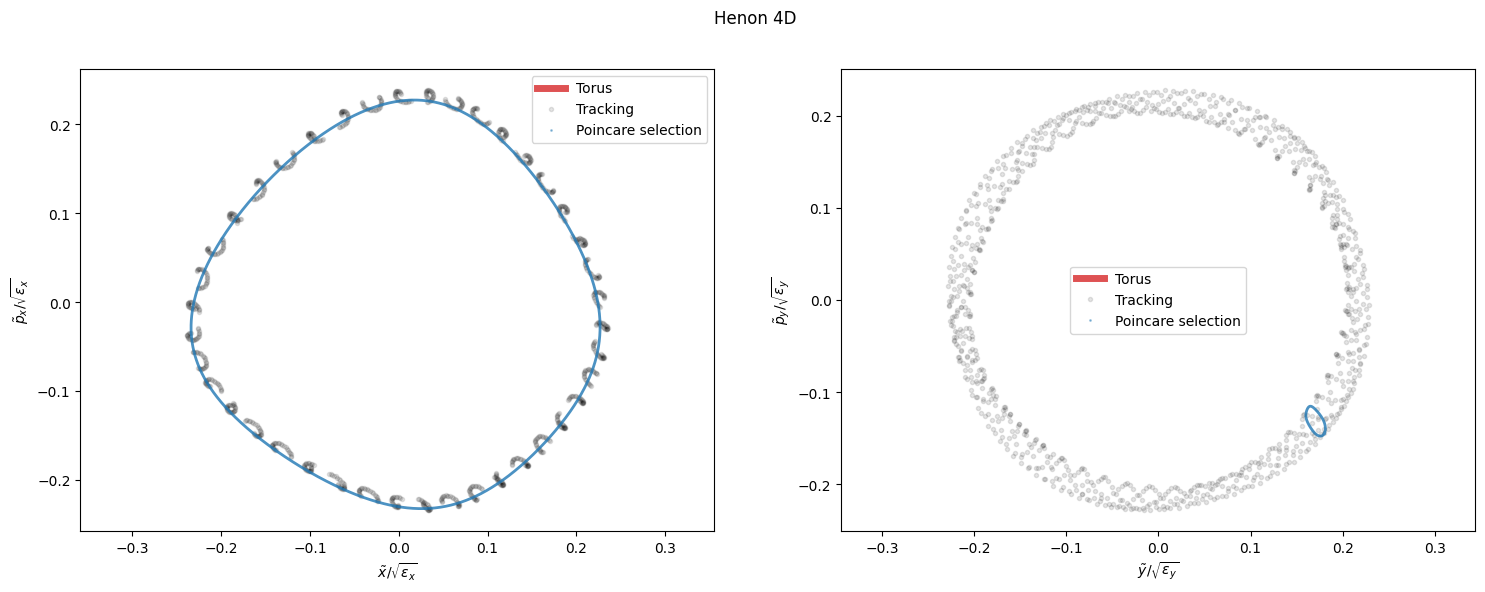

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sciStat
import nafflib

import sys
sys.path.append('/Users/pbelanger/ABPLocal/pytori')
import pytori.torus as pytorus




# Henon parameters:
# ---
nturns = int(1e6)

points = np.array([0.2])

slope  = 0.35

coupling = 0.25
Qx_list = [0.2064898024701758,0.2264898024701758, (3 - np.sqrt(5)) / 2]
Qx = 0.24464898024701758
Qy = np.sqrt(2) - 1
# ------------

particles = []
for point in points:
    
    # Tracking
    x,px,y,py = nafflib.henon_map_4D(point,slope*point,point,slope*point,   Qx = Qx,
                                                                            Qy = Qy,
                                                                            coupling = coupling,
                                                                            num_turns= nturns)
    # Saving
    dct = {'x':x,'px':px,'y':y,'py':py}
    particles.append(dct)


    
n_harm = 300
from fractions import Fraction
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.suptitle('Henon 4D')
for p_idx,part in enumerate(particles):
    
    fundamental_tunes = [nafflib.tune(part[plane][:int(5e4)],part[f'p{plane}'][:int(5e4)],window_order=4) for plane in ['x','y']]

    N_start = 10


    Ax,Qx  = nafflib.harmonics( part['x'][:int(5e4)],part[f'px'][:int(5e4)],num_harmonics = n_harm,window_order=4)
    Cx = nafflib.linear_combinations(Qx,Qvec=fundamental_tunes,max_n=40)

    Ay,Qy  = nafflib.harmonics( part['y'][:int(5e4)],part[f'py'][:int(5e4)],num_harmonics = n_harm,window_order=4)
    Cy = nafflib.linear_combinations(Qy,Qvec=fundamental_tunes,max_n=40)

    mytorus = pytorus.Torus(Ax,Ay,Cx,Cy)
        

    theta_vec   = 2 * np.pi*fundamental_tunes[0]* N_start + np.linspace(0,2*np.pi,1000)
    theta_slice = 2 * np.pi*fundamental_tunes[1]* N_start
        

    slice_x,slice_y = mytorus.slice('x',theta_vec,theta_slice)
    slice_x,slice_y = slice_x[0],slice_y[0]



    plt.sca(axes[0])
    plane = 'x'
    plt.plot(slice_x[:,0],slice_x[:,1],'-',lw=2,alpha=0.8,zorder=-10)
    plt.plot(part[plane][:1000],part[f'p{plane}'][:1000],'.',color='k',alpha=0.1,zorder=-20)


    plt.sca(axes[1])
    plane = 'y'
    plt.plot(slice_y[:,0],slice_y[:,1],'-',lw=2,alpha=0.8,zorder=-10)
    plt.plot(part[plane][:1000],part[f'p{plane}'][:1000],'.',color='k',alpha=0.1,zorder=-20)

# Adding labels
for plane,ax in zip(['x','y','zeta'],axes):
    plt.sca(ax)
    plt.axis('equal')
    if plane == 'zeta':
        plane = '\zeta'
    plt.xlabel(rf'$\tilde {plane}/\sqrt{{\varepsilon_{plane}}}$')
    plt.ylabel(rf'$\tilde p_{plane}/\sqrt{{\varepsilon_{plane}}}$')

    plt.plot(np.nan,np.nan,'-',lw=5,color='C3',alpha=0.8,zorder=-10,label='Torus')
    plt.plot(np.nan,np.nan,'.',color='k',alpha=0.1,label='Tracking')
    plt.plot(np.nan,np.nan,'.',ms=2,color='C0',alpha=0.4,label='Poincare selection')

    plt.legend()

    # plt.xlim(-0.5,0.5)
    # plt.ylim(-0.5,0.5)


plt.sca(axes[0])
# plt.xlim(-0.5,-0.25)
# plt.ylim(0,0.2)



In [3]:
mytorus.Ax

array([ 2.02450146e-01-9.01288977e-02j,  9.80394406e-03+9.47974080e-03j,
        3.34273199e-04+9.41602687e-03j, -8.74761439e-03-1.63064461e-05j,
        3.00682036e-03+7.49549685e-03j, -4.97018838e-03-4.18159292e-03j,
       -1.02460313e-03-1.13787956e-03j, -5.58637724e-04+5.36148824e-04j,
        4.40901858e-04-4.91447690e-04j,  5.98180097e-04-3.17521478e-04j,
       -5.64483357e-04-2.04694919e-04j, -1.97567943e-04+4.87238731e-04j,
       -4.42936975e-04+1.61534921e-04j, -1.73511663e-04-3.53585183e-04j,
        1.73424125e-04-3.55044270e-04j,  8.99827857e-05-2.75138967e-04j,
       -1.89636343e-04-1.34886753e-05j,  6.11677962e-06+5.82469868e-05j,
        1.91837869e-06-5.69714296e-05j, -1.69259272e-05-5.24147615e-05j,
        4.28069022e-05-3.12337425e-06j,  1.34430200e-06-3.42638215e-05j,
       -2.85650636e-05-1.28447132e-05j, -2.70103873e-05-7.72984650e-06j,
       -9.75433399e-06+1.25141724e-05j, -1.14973645e-05-8.38811996e-06j,
        5.71186740e-06+1.18050764e-05j,  1.29186286

In [27]:
plt.close('all')

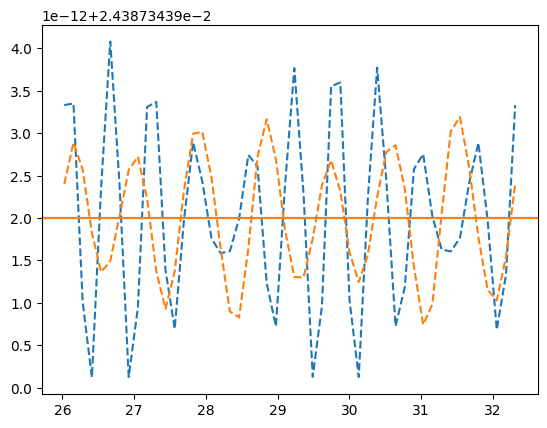

In [4]:

from shapely import Polygon  

theta_vec   = 2 * np.pi*fundamental_tunes[0]* N_start + np.linspace(0,2*np.pi,10000)
theta_slice = 2 * np.pi*fundamental_tunes[1]* N_start + np.linspace(0,2*np.pi,50)

plt.figure()
for stop_at,color in zip([200,300],['C0','C1','C2','C3','C4']):
    mytorus_test = pytorus.Torus(mytorus.Ax[:stop_at],mytorus.Ay[:stop_at],mytorus.nx[:stop_at],mytorus.ny[:stop_at])
    slice_x,slice_y = mytorus_test.slice('x',theta_vec,theta_slice)

    Ixx = []
    Ixy = []
    Ix  = []
    Jx  = []
    for _sx,_sy,id in zip(slice_x,slice_y,np.arange(len(slice_x))):
        
        x_polygon = Polygon([(_x,_px) for _x,_px in zip(_sx[:,0],_sx[:,1])])
        y_polygon = Polygon([(_x,_px) for _x,_px in zip(_sy[:,0],_sy[:,1])])

        
        Ixx.append(x_polygon.area)
        Ixy.append(-y_polygon.area)
        Ix.append(x_polygon.area - y_polygon.area)

        Jx.append(np.mean(_sx[:,0]**2 + _sx[:,1]**2))

    Ixx = np.array(Ixx)/np.pi/2
    Ixy = np.array(Ixy)/np.pi/2
    Ix  = np.array(Ix)/np.pi/2
    Jx  = np.array(Jx)/2


    
    # plt.plot(theta_slice,   Ixx + (Ix[0]-Ixx[0])    ,'-',color='C0' ,lw=4,alpha=0.3,label='Ixx')
    # plt.plot(theta_slice,   Ixy + (Ix[0]-Ixy[0])    ,'-',color='C1' ,lw=4,alpha=0.3,label='Ixy')
    # plt.plot(theta_slice,   Ix                      ,'-',color='C3' ,lw=4,alpha=0.3,label='Ix')
    # plt.plot(theta_slice,   Jx                      ,'-',color='k'  ,lw=4,alpha=0.3,label='Jx')

    area_test = np.array([compute_area(mytorus_test,theta) for theta in theta_slice])
    # plt.plot(theta_slice,   area_test[:,0]+ (Ix[0]-area_test[:,0][0])    ,'--' ,label='Ixx_test')
    # plt.plot(theta_slice,   area_test[:,1]+ (Ix[0]-area_test[:,1][0])    ,'--' ,label='Ixy_test')

    # plt.axhline(mytorus.Ix,ls='--',color='C4')

    plt.plot(theta_slice,np.sum(area_test,axis=1),'--',color=color)
    plt.axhline(mytorus_test.Ix,ls='-',color=color)
# plt.legend()
plt.show()


In [5]:
%matplotlib widget

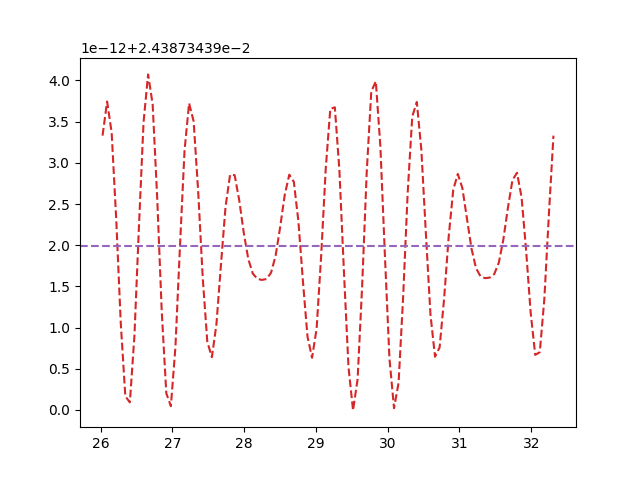

In [7]:
plt.figure()
# plt.plot(theta_slice,   Ixy + Ixx                      ,'-',color='C3' ,lw=4,alpha=0.3,label='Ix')
plt.plot(theta_slice,np.sum(area_test,axis=1),'--',color='C3')
plt.axhline(mytorus.Ix,ls='--',color='C4')


In [7]:
np.mean(np.sum(area_test,axis=1)) - mytorus.Ix

1.3475331961387838e-14

In [62]:
(np.max(np.sum(area_test,axis=1)) - np.min(np.sum(area_test,axis=1)))/2

2.0284988966334794e-12

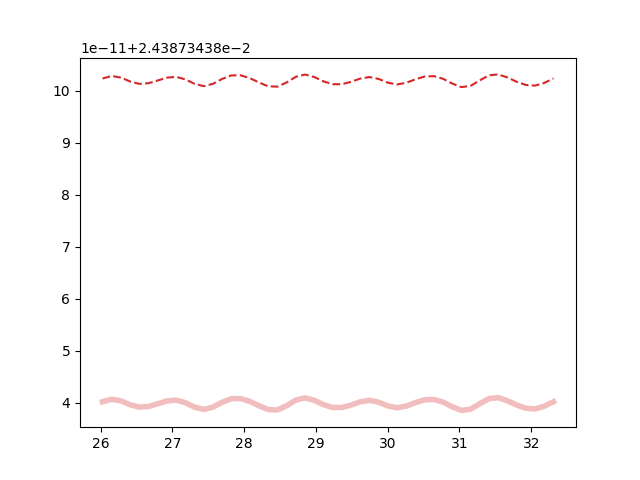

In [24]:
plt.figure()
plt.plot(theta_slice,   Ixy + Ixx                      ,'-',color='C3' ,lw=4,alpha=0.3,label='Ix')
plt.plot(theta_slice,np.sum(area_test,axis=1),'--',color='C3')


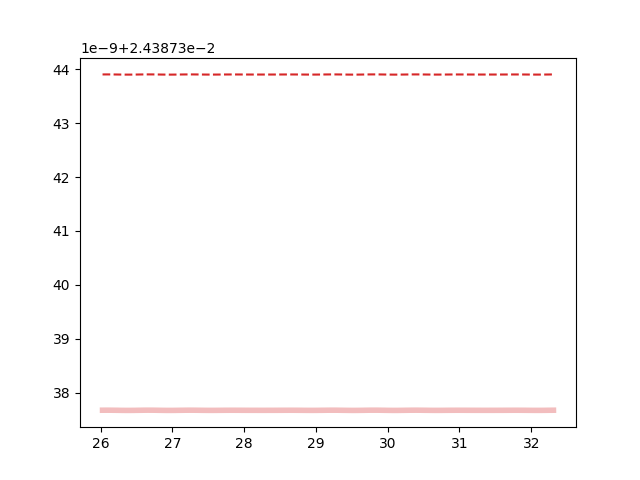

In [12]:
plt.figure()
plt.plot(theta_slice,   Ixy + Ixx                      ,'-',color='C3' ,lw=4,alpha=0.3,label='Ix')
plt.plot(theta_slice,area_test[:,0] + area_test[:,1],'--',color='C3')


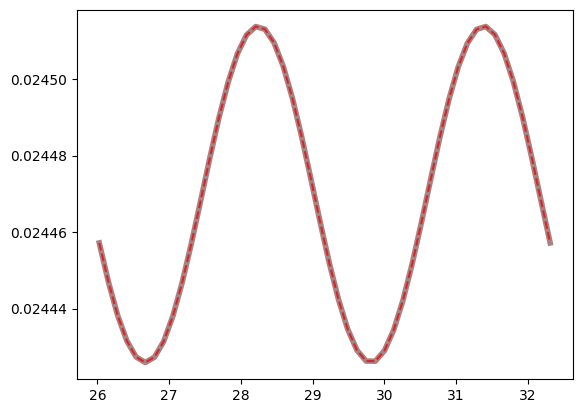

In [5]:
import nafflib.naomi as mi
Thetay = np.linspace(0,2*np.pi,1000)
Ixx_test = mi.pdq_integral(mytorus.Ax,mytorus.nx,theta_slice,idx=0)
Ixy_test = mi.pdq_integral(mytorus.Ay,mytorus.ny,theta_slice,idx=0)
Deltaxx_test = Ixx_test - mi.pdq_avg_integral(mytorus.Ax,mytorus.nx,idx=0)
Deltaxy_test = Ixy_test - mi.pdq_avg_integral(mytorus.Ay,mytorus.ny,idx=0)

plt.figure()
plt.plot(theta_slice,   Ixx  ,'-',color='C3' ,lw=4,alpha=0.3,label='Ix')
plt.plot(theta_slice,   Ixx_test  ,'-',color='k' ,lw=4,alpha=0.3,label='Ix')
plt.plot(theta_slice, area_test[:,0] ,'--',color='C3')




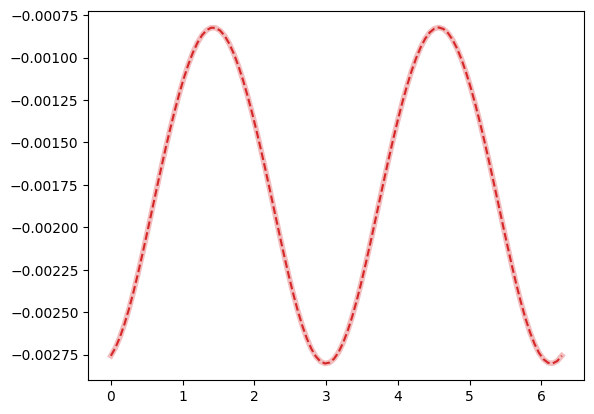

In [29]:
plt.figure()
plt.plot(theta_slice,   Ixy  ,'-',color='C3' ,lw=4,alpha=0.3,label='Ix')
plt.plot(theta_slice, area_test[:,1] ,'--',color='C3')

In [11]:
area_test = np.array([compute_area(mytorus,theta) for theta in theta_slice])

In [3]:
def compute_area(torus,theta):
    phi = [n[1]*theta + np.angle(A) for n,A in zip(torus.nx,torus.Ax)]
    a   = [np.abs(A) for A in torus.Ax]

    Ixx_area = 1/2 * sum(ak*aj*nj[0]*np.cos(phij-phik) for nk,ak,phik in zip(torus.nx,a,phi) for nj,aj,phij in zip(torus.nx,a,phi) if nj[0]==nk[0])


    phi = [n[1]*theta + np.angle(A) for n,A in zip(torus.ny,torus.Ay)]
    a   = [np.abs(A) for A in torus.Ay]

    Iyy_area = 1/2 * sum(ak*aj*nj[0]*np.cos(phij-phik) for nk,ak,phik in zip(torus.ny,a,phi) for nj,aj,phij in zip(torus.ny,a,phi) if nj[0]==nk[0])
    
    return Ixx_area,Iyy_area




In [54]:
theta = theta_slice
torus = mytorus
phi1 = [n[1]*theta + np.angle(A) for n,A in zip(torus.nx,torus.Ax)]
a1   = [np.abs(A) for A in torus.Ax]

Ixx_area = 1/2 * sum(ak*aj*nj[0]*np.cos(phij-phik) for nk,ak,phik in zip(torus.nx,a1,phi1) for nj,aj,phij in zip(torus.nx,a1,phi1) if nj[0]==nk[0])



Theta = theta_slice
A = mytorus.Ax
n = mytorus.nx
idx = 0
if not isinstance(Theta,list):
    Theta = [Theta]
assert len(Theta) == len(n[0])-2, 'Theta should include all non-integrated angles, i.e. [Theta_y,Theta_zeta] for x-plane integration'

# Computing the non-integrated phase
n_tmp   = [nk[:idx] + nk[idx+1:] for nk in n]
phi     = [np.angle(Ak) + sum([nk[i]*Theta[i] for i in range(len(Theta))]) for Ak,nk in zip(A,n_tmp)]

# Computing the full integral
test= 1/2 * sum(np.abs(Ak)*np.abs(Aj)*nj[idx]*np.cos(phik-phij)    for nk,Ak,phik in zip(n,A,phi) 
                                                                    for nj,Aj,phij in zip(n,A,phi) 
                                                                    if nj[idx]==nk[idx])
    

In [55]:
phi

[array([-0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722]),
 array([0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.76858744,
        0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.76858744,
        0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.76858744,
        0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.768587

In [56]:
phi1

[array([-0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722]),
 array([0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.76858744,
        0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.76858744,
        0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.76858744,
        0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.768587

In [52]:
[nk[:idx] + nk[idx+1:] for nk in n]

[(0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 1),
 (-2, 1),
 (2, -1),
 (0, 1),
 (0, -1),
 (-2, 1),
 (0, -1),
 (0, 0),
 (2, -1),
 (0, -1),
 (2, -1),
 (-2, 1),
 (2, 0),
 (-2, 0),
 (2, -1),
 (2, 0),
 (0, -1),
 (0, 1),
 (0, 1),
 (-2, 0),
 (-2, 0),
 (-4, 2),
 (-2, 2),
 (-2, 1),
 (0, 2),
 (2, -2),
 (-2, 2),
 (2, 0),
 (4, -2),
 (4, -1),
 (-2, 0),
 (0, 2),
 (4, -1),
 (6, -2),
 (0, -2),
 (-4, 1),
 (0, -2),
 (2, -2),
 (2, 0),
 (-2, 2),
 (2, -2),
 (-6, 2),
 (0, -2),
 (-4, 2),
 (-4, 1),
 (2, 1),
 (4, -2),
 (-4, 1),
 (2, 1),
 (4, -1),
 (-6, 3),
 (4, -2),
 (-2, -1),
 (-6, 2),
 (6, -2),
 (-2, 3),
 (2, -2),
 (6, -2),
 (0, 2),
 (-6, 2),
 (-4, 1),
 (-2, -1),
 (6, -1),
 (0, -2),
 (4, -2),
 (0, 2),
 (-6, 2),
 (6, -2),
 (-2, -1),
 (-4, 2),
 (2, -4),
 (-4, 2),
 (4, 0),
 (-4, 3),
 (4, -1),
 (-8, 3),
 (-6, 3),
 (2, 1),
 (6, -3),
 (-2, 2),
 (0, 3),
 (6, -3),
 (-6, 2),
 (2, -3),
 (6, -3),
 (6, -1),
 (-2, 3),
 (4, -3),
 (-2, 3),
 (-2, -1),
 (-6, 1),
 (4, 0),
 (2, -3),
 (0, 3),
 (2, -3),
 (-6, 1),
 (-6, 1),
 (-4, 0),


In [45]:
[n[1] for n,A in zip(torus.nx,torus.Ax)]

[0,
 0,
 0,
 0,
 0,
 -2,
 2,
 0,
 0,
 -2,
 0,
 0,
 2,
 0,
 2,
 -2,
 2,
 -2,
 2,
 2,
 0,
 0,
 0,
 -2,
 -2,
 -4,
 -2,
 -2,
 0,
 2,
 -2,
 2,
 4,
 4,
 -2,
 0,
 4,
 6,
 0,
 -4,
 0,
 2,
 2,
 -2,
 2,
 -6,
 0,
 -4,
 -4,
 2,
 4,
 -4,
 2,
 4,
 -6,
 4,
 -2,
 -6,
 6,
 -2,
 2,
 6,
 0,
 -6,
 -4,
 -2,
 6,
 0,
 4,
 0,
 -6,
 6,
 -2,
 -4,
 2,
 -4,
 4,
 -4,
 4,
 -8,
 -6,
 2,
 6,
 -2,
 0,
 6,
 -6,
 2,
 6,
 6,
 -2,
 4,
 -2,
 -2,
 -6,
 4,
 2,
 0,
 2,
 -6,
 -6,
 -4,
 2,
 0,
 8,
 -8,
 -4,
 -4,
 -2,
 2,
 0,
 -4,
 6,
 2,
 -2,
 -2,
 2,
 8,
 4,
 8,
 6,
 4,
 8,
 4,
 0,
 2,
 -6,
 -6,
 -4,
 -8,
 2,
 -6,
 8,
 6,
 8,
 -4,
 -6,
 -4,
 4,
 -8,
 -2,
 -2,
 6,
 -2,
 -2,
 2,
 -2,
 0,
 -4,
 -2,
 -8,
 2,
 2,
 6,
 2,
 -2,
 -8,
 4,
 -8,
 -6,
 -2,
 -8,
 4,
 4,
 4,
 2,
 6,
 -8,
 4,
 -4,
 6,
 0,
 8,
 -4,
 6,
 -10,
 6,
 8,
 -4,
 -6,
 -4,
 -8,
 0,
 -4,
 4,
 8,
 -2,
 0,
 4,
 -6,
 -4,
 2,
 4,
 -8,
 -6,
 -2,
 10,
 4,
 10,
 8,
 8,
 -4,
 10,
 -2,
 4,
 4,
 -10,
 4,
 -4,
 -4,
 2,
 0,
 -3,
 -6,
 4,
 4,
 8,
 -4,
 4,
 8,
 -8,
 4,
 12,
 2,
 6,


In [48]:
n_tmp

[(0, 0, 0),
 (2, 0, 0),
 (-2, 0, 0),
 (-3, 0, 1),
 (0, -2, 1),
 (0, 2, -1),
 (-4, 0, 1),
 (4, 0, -1),
 (1, -2, 1),
 (3, 0, -1),
 (-1, 0, 0),
 (1, 2, -1),
 (5, 0, -1),
 (-1, 2, -1),
 (-1, -2, 1),
 (-2, 2, 0),
 (2, -2, 0),
 (2, 2, -1),
 (-3, 2, 0),
 (6, 0, -1),
 (-6, 0, 1),
 (-5, 0, 1),
 (3, -2, 0),
 (4, -2, 0),
 (0, -4, 2),
 (-3, -2, 2),
 (-2, -2, 1),
 (-7, 0, 2),
 (3, 2, -2),
 (-4, -2, 2),
 (-4, 2, 0),
 (0, 4, -2),
 (-1, 4, -1),
 (5, -2, 0),
 (-8, 0, 2),
 (-2, 4, -1),
 (-1, 6, -2),
 (8, 0, -2),
 (1, -4, 1),
 (7, 0, -2),
 (5, 2, -2),
 (-5, 2, 0),
 (-5, -2, 2),
 (4, 2, -2),
 (3, -6, 2),
 (9, 0, -2),
 (-1, -4, 2),
 (2, -4, 1),
 (-6, 2, 1),
 (1, 4, -2),
 (3, -4, 1),
 (-7, 2, 1),
 (-3, 4, -1),
 (-1, -6, 3),
 (2, 4, -2),
 (6, -2, -1),
 (2, -6, 2),
 (-2, 6, -2),
 (-8, -2, 3),
 (6, 2, -2),
 (0, 6, -2),
 (-9, 0, 2),
 (0, -6, 2),
 (4, -4, 1),
 (7, -2, -1),
 (-5, 6, -1),
 (10, 0, -2),
 (3, 4, -2),
 (-10, 0, 2),
 (4, -6, 2),
 (-4, 6, -2),
 (8, -2, -1),
 (-2, -4, 2),
 (14, 2, -4),
 (-3, -4, 2),
 (-

In [47]:
torus.nx

[(1, 0, 0),
 (0, 0, 0),
 (2, 0, 0),
 (-2, 0, 0),
 (-3, 0, 1),
 (0, -2, 1),
 (0, 2, -1),
 (-4, 0, 1),
 (4, 0, -1),
 (1, -2, 1),
 (3, 0, -1),
 (-1, 0, 0),
 (1, 2, -1),
 (5, 0, -1),
 (-1, 2, -1),
 (-1, -2, 1),
 (-2, 2, 0),
 (2, -2, 0),
 (2, 2, -1),
 (-3, 2, 0),
 (6, 0, -1),
 (-6, 0, 1),
 (-5, 0, 1),
 (3, -2, 0),
 (4, -2, 0),
 (0, -4, 2),
 (-3, -2, 2),
 (-2, -2, 1),
 (-7, 0, 2),
 (3, 2, -2),
 (-4, -2, 2),
 (-4, 2, 0),
 (0, 4, -2),
 (-1, 4, -1),
 (5, -2, 0),
 (-8, 0, 2),
 (-2, 4, -1),
 (-1, 6, -2),
 (8, 0, -2),
 (1, -4, 1),
 (7, 0, -2),
 (5, 2, -2),
 (-5, 2, 0),
 (-5, -2, 2),
 (4, 2, -2),
 (3, -6, 2),
 (9, 0, -2),
 (-1, -4, 2),
 (2, -4, 1),
 (-6, 2, 1),
 (1, 4, -2),
 (3, -4, 1),
 (-7, 2, 1),
 (-3, 4, -1),
 (-1, -6, 3),
 (2, 4, -2),
 (6, -2, -1),
 (2, -6, 2),
 (-2, 6, -2),
 (-8, -2, 3),
 (6, 2, -2),
 (0, 6, -2),
 (-9, 0, 2),
 (0, -6, 2),
 (4, -4, 1),
 (7, -2, -1),
 (-5, 6, -1),
 (10, 0, -2),
 (3, 4, -2),
 (-10, 0, 2),
 (4, -6, 2),
 (-4, 6, -2),
 (8, -2, -1),
 (-2, -4, 2),
 (14, 2, -4),
 (-3,

In [46]:
[nk[0] for Ak,nk in zip(A,n_tmp)]

[0,
 2,
 -2,
 -3,
 0,
 0,
 -4,
 4,
 1,
 3,
 -1,
 1,
 5,
 -1,
 -1,
 -2,
 2,
 2,
 -3,
 6,
 -6,
 -5,
 3,
 4,
 0,
 -3,
 -2,
 -7,
 3,
 -4,
 -4,
 0,
 -1,
 5,
 -8,
 -2,
 -1,
 8,
 1,
 7,
 5,
 -5,
 -5,
 4,
 3,
 9,
 -1,
 2,
 -6,
 1,
 3,
 -7,
 -3,
 -1,
 2,
 6,
 2,
 -2,
 -8,
 6,
 0,
 -9,
 0,
 4,
 7,
 -5,
 10,
 3,
 -10,
 4,
 -4,
 8,
 -2,
 14,
 -3,
 -6,
 -4,
 -4,
 2,
 -2,
 -8,
 2,
 -6,
 -11,
 3,
 1,
 9,
 1,
 -6,
 -9,
 4,
 -7,
 9,
 6,
 -5,
 8,
 -12,
 7,
 7,
 5,
 5,
 10,
 12,
 -2,
 3,
 -5,
 6,
 -16,
 -9,
 11,
 7,
 -3,
 15,
 -15,
 -13,
 13,
 -3,
 -7,
 -4,
 4,
 5,
 -1,
 6,
 13,
 -11,
 -4,
 -3,
 8,
 1,
 -10,
 8,
 0,
 -8,
 -5,
 -6,
 -5,
 -13,
 -10,
 4,
 -17,
 -12,
 -7,
 11,
 10,
 17,
 -10,
 -13,
 -8,
 -11,
 5,
 18,
 11,
 -9,
 16,
 12,
 6,
 -14,
 -2,
 -6,
 -14,
 0,
 8,
 7,
 -8,
 -12,
 6,
 -1,
 13,
 -9,
 5,
 14,
 1,
 16,
 -10,
 2,
 7,
 -6,
 -7,
 10,
 11,
 7,
 -14,
 -12,
 -11,
 3,
 13,
 -15,
 14,
 9,
 10,
 19,
 9,
 -3,
 11,
 -19,
 -3,
 12,
 -4,
 2,
 -7,
 -14,
 -2,
 -18,
 11,
 -9,
 3,
 -13,
 9,
 13,
 -13,
 15

In [41]:
np.shape(phi)

(299, 50)

In [42]:
np.shape(phi1)

(300, 50)

In [39]:
phi

[array([-0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722]),
 array([52.82134035, 53.07779689, 53.33425344, 53.59070998, 53.84716652,
        54.10362307, 54.36007961, 54.61653615, 54.87299269, 55.12944924,
        55.38590578, 55.64236232, 55.89881887, 56.15527541, 56.41173195,
        56.6681885 , 56.92464504, 57.18110158, 57

In [40]:
phi1

[array([-0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722,
        -0.41884722, -0.41884722, -0.41884722, -0.41884722, -0.41884722]),
 array([0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.76858744,
        0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.76858744,
        0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.76858744,
        0.76858744, 0.76858744, 0.76858744, 0.76858744, 0.768587